# global ocean simulation on a lat/lon grid

**01 July 2023 by MiniUFO**

---


## 1. 简介


本案例是MITgcm模型自带的运行案（verification/tutorial_global_oce_latlon）例，通过调整

- 功能包（package.conf）
- 网格数（SIZE.h）
- 大气强迫场件data.exf
- 海洋初始场（U/V/T/S）
- 地形（topo.bin）
- 模式诊断包放data.diagnosticsn）

等文件可以修改本案例的多种功能和参数。下面分别进行介绍

---

## 2. 准备步骤

### 2.1 修改功能包

功能包（code/package.conf）

- [ ] 去掉timeave，**不需要**时间平均模块，diagnostics功能更强大；
- [ ] 去掉mnc，**不需要**模式输出为nc格式，减少了模式编译依赖和麻烦，后期用xmitgcm读取数据；
- [ ] 增加exf，加入大气上边界强迫（external forcings）；
- [ ] 增加diagnostics，用于选取模式状态变量或诊断量的输出。

### 2.2 修改功网格数

网格数（code/SIZE.h）

- [ ] 设计网格规模nz * ny * nx，如果是并行，用N个核模拟，则需要保证**ny * nx可以整除N**。垂向无法分块（tile），仅在水平方向上分；
- [ ] 当功能包和网格都定下来后，可以进行编译。涉及这两个功能的参数都是**编译时参数**，需要在编译前确定下来


In [ ]:
import numpy as np
import xarray as xr

# 确定网格规模，默认是4度分辨率（40个纬度 * 90个经度）
# 修改为2度分辨率（90个纬度 * 180个经度）
# 垂向默认15层，改为22层
nz, ny, nx = 22, 90, 180

# 分辨率（度）
reso = 2.0

# x, y坐标，u、v和tracer错开半个网格
# u从（0，-79）开始
# v从（1，-80）开始
# T从（1，-79）开始
XG = np.arange(  0.0, 360, reso)
XC = np.arange(  0.0+reso/2.0, 360, reso)
YG = np.arange(-80.0,  80, reso)
YC = np.arange(-80.0+reso/2.0,  80, reso)

# 打包成xarray
XG = xr.DataArray(XG, dims='XG', coords={'XG':XG}).astype('>f4')
XC = xr.DataArray(XC, dims='XC', coords={'XC':XC}).astype('>f4')
YG = xr.DataArray(YG, dims='YG', coords={'YG':YG}).astype('>f4')
YC = xr.DataArray(YC, dims='YC', coords={'YC':YC}).astype('>f4')

print(XG)
print(XC)
print(YG)
print(YC)

<xarray.DataArray (XG: 180)>
array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
        22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
        44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
        66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
        88.,  90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108.,
       110., 112., 114., 116., 118., 120., 122., 124., 126., 128., 130.,
       132., 134., 136., 138., 140., 142., 144., 146., 148., 150., 152.,
       154., 156., 158., 160., 162., 164., 166., 168., 170., 172., 174.,
       176., 178., 180., 182., 184., 186., 188., 190., 192., 194., 196.,
       198., 200., 202., 204., 206., 208., 210., 212., 214., 216., 218.,
       220., 222., 224., 226., 228., 230., 232., 234., 236., 238., 240.,
       242., 244., 246., 248., 250., 252., 254., 256., 258., 260., 262.,
       264., 266., 268., 270., 272., 274., 276., 278., 280., 282., 284.,
       286., 288., 290

### 2.3 设置地形

这里我们采用ETOPO5地形数据，并进行稀疏化，得到目标网格的地形：

- [ ] 下载得到ETOPO5地形；
- [ ] 稀疏化；
- [ ] mask掉内陆湖；

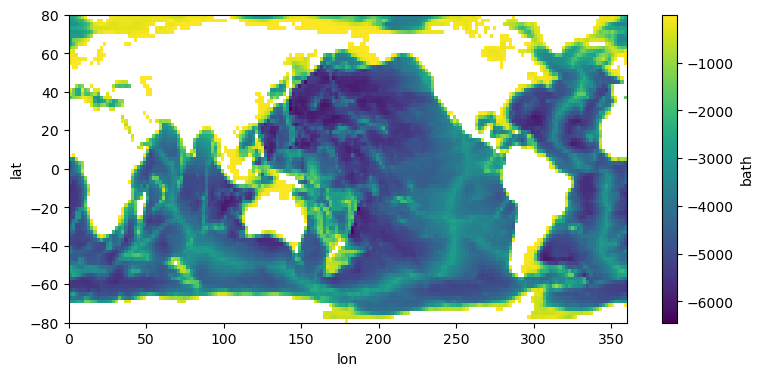

In [2]:
import xarray as xr

path = 'ETOPO/'
fontsize = 13

dsBath = xr.open_dataset(path + 'ETOPO5.cdf')

# 1/12度 -> 2度
bath = dsBath.bath.coarsen({'Y':24, 'X':24}, boundary='trim').mean().astype('>f4')
bath = xr.where(bath<0, bath, 0).rename({'X':'lon', 'Y':'lat'}).sel(lat=slice(-80,80))
bath['lon'] = XC.values
bath['lat'] = YC.values

bath.where(bath!=0).plot(figsize=(9,4))

### 2.4 准备大气强迫

主要步骤:

- [ ] 根据手头上的资料，以及pkg/exf/EXF_OPTIONS.h，准备强迫“套餐”；
- [ ] 根据“套餐”，下载完整所需资料，并插值到目标网格。

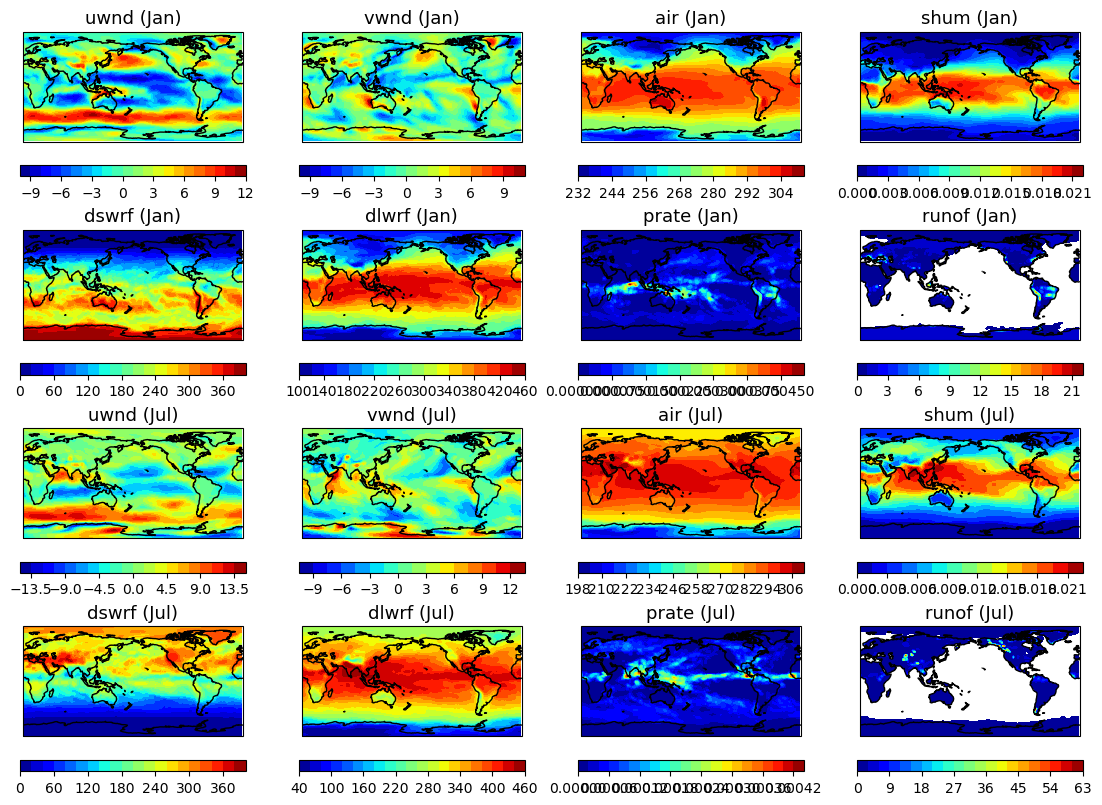

In [5]:
# 选择“套餐4”需要：10m风场、2m温度、2m比湿、长波辐射、短波辐射、降水、径流 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

path = 'NCEP/'
fontsize = 13

ds1 = xr.open_dataset(path +  'uwnd.10m.mon.mean.nc')
ds2 = xr.open_dataset(path +  'vwnd.10m.mon.mean.nc')
ds3 = xr.open_dataset(path +    'air.2m.mon.mean.nc')
ds4 = xr.open_dataset(path +   'shum.2m.mon.mean.nc')
ds5 = xr.open_dataset(path + 'dswrf.sfc.mon.mean.nc')
ds6 = xr.open_dataset(path + 'dlwrf.sfc.mon.mean.nc')
ds7 = xr.open_dataset(path + 'prate.sfc.mon.mean.nc')
ds8 = xr.open_dataset(path + 'runof.sfc.mon.mean.nc')

def plot(ax, var, title):
    m = ax.contourf(var.lon, var.lat, var, levels=21, cmap='jet', transform=ccrs.PlateCarree())
    plt.colorbar(m, ax=ax, location='bottom')
    ax.set_title(title, fontsize=fontsize)
    ax.coastlines()
    ax.set_xlim([-180, 180])
    ax.set_ylim([-90, 90])

fig, axes = plt.subplots(4, 4, figsize=(11, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

plot(axes[0,0], ds1.uwnd[0,0], 'uwnd (Jan)' )
plot(axes[0,1], ds2.vwnd[0,0], 'vwnd (Jan)' )
plot(axes[0,2], ds3.air [0,0], 'air (Jan)'  )
plot(axes[0,3], ds4.shum[0,0], 'shum (Jan)' )
plot(axes[1,0], ds5.dswrf[0] , 'dswrf (Jan)')
plot(axes[1,1], ds6.dlwrf[0] , 'dlwrf (Jan)')
plot(axes[1,2], ds7.prate[0] , 'prate (Jan)')
plot(axes[1,3], ds8.runof[0] , 'runof (Jan)')

plot(axes[2,0], ds1.uwnd[6,0], 'uwnd (Jul)' )
plot(axes[2,1], ds2.vwnd[6,0], 'vwnd (Jul)' )
plot(axes[2,2], ds3.air [6,0], 'air (Jul)'  )
plot(axes[2,3], ds4.shum[6,0], 'shum (Jul)' )
plot(axes[3,0], ds5.dswrf[6] , 'dswrf (Jul)')
plot(axes[3,1], ds6.dlwrf[6] , 'dlwrf (Jul)')
plot(axes[3,2], ds7.prate[6] , 'prate (Jul)')
plot(axes[3,3], ds8.runof[6] , 'runof (Jul)')

fig.tight_layout(pad=0.5)

插值到目标网格，需要保证全场没有缺测值，如果有缺测值，需要填补完缺测值（例如用fill_na函数）再插值。NCEP大气强迫并不存在这样的问题，后面做海洋初始场会存在这样的问题。

In [6]:
# 注意网格定义
def pad_periodic(var, dim):
    deldim = var[dim][1] - var[dim][0]
    var2 = var.pad({dim:1}, mode='wrap')
    coord = var2[dim].copy().values
    coord[ 0] = coord[ 1] - deldim.values
    coord[-1] = coord[-2] + deldim.values
    var2[dim] = coord
    
    return var2
    
u10Interp = pad_periodic(ds1.uwnd , 'lon').interp({'lon':XG, 'lat':YC})
v10Interp = pad_periodic(ds2.vwnd , 'lon').interp({'lon':XC, 'lat':YG})
T2mInterp = pad_periodic(ds3.air  , 'lon').interp({'lon':XC, 'lat':YC})
sh2Interp = pad_periodic(ds4.shum , 'lon').interp({'lon':XC, 'lat':YC})
dswInterp = pad_periodic(ds5.dswrf, 'lon').interp({'lon':XC, 'lat':YC})
dlwInterp = pad_periodic(ds6.dlwrf, 'lon').interp({'lon':XC, 'lat':YC})
prtInterp = pad_periodic(ds7.prate, 'lon').interp({'lon':XC, 'lat':YC})
runInterp = pad_periodic(ds8.runof, 'lon').interp({'lon':XC, 'lat':YC})

In [7]:
assert np.isnan(u10Interp).any() == False
assert np.isnan(v10Interp).any() == False
assert np.isnan(T2mInterp).any() == False
assert np.isnan(sh2Interp).any() == False
assert np.isnan(dswInterp).any() == False
assert np.isnan(dlwInterp).any() == False
assert np.isnan(prtInterp).any() == False

### 2.5 准备海洋初始场

四个状态变量：U，V，T，S

- [ ] 采用SODA再分析产品（0.5度分辨率）；
- [ ] 填充缺测值；
- [ ] 采用interp进行插值（Uinit.bin，Vinit.bin，Tinit.bin，Sinit.bin）；

[5.01000e+00 1.50700e+01 2.52800e+01 3.57600e+01 4.66100e+01 5.79800e+01
 7.00200e+01 8.29200e+01 9.69200e+01 1.12320e+02 1.29490e+02 1.48960e+02
 1.71400e+02 1.97790e+02 2.29480e+02 2.68460e+02 3.17650e+02 3.81390e+02
 4.65910e+02 5.79310e+02 7.29350e+02 9.18370e+02 1.13915e+03 1.37857e+03
 1.62570e+03 1.87511e+03 2.12501e+03 2.37500e+03 2.62500e+03 2.87500e+03
 3.12500e+03 3.37500e+03 3.62500e+03 3.87500e+03 4.12500e+03 4.37500e+03
 4.62500e+03 4.87500e+03 5.12500e+03 5.37500e+03]


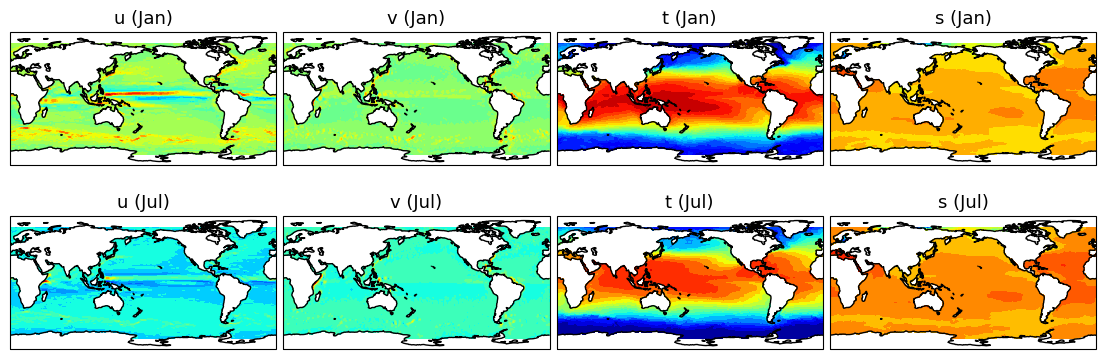

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

path = 'SODA/'
fontsize = 13

ds = xr.open_dataset(path + 'SODAClim.nc', chunks={'time':1})
u  = ds.u   .where(ds.u   !=ds.undef) # maskout land as nan
v  = ds.v   .where(ds.u   !=ds.undef) # maskout land as nan
t  = ds.temp.where(ds.temp!=ds.undef) # maskout land as nan
s  = ds.salt.where(ds.salt!=ds.undef) # maskout land as nan

print(ds.lev.values)

def plot(ax, var, title):
    m = ax.contourf(var.lon, var.lat, var, levels=21, cmap='jet', transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=fontsize)
    ax.coastlines()
    ax.set_xlim([-180, 180])
    ax.set_ylim([-90, 90])

fig, axes = plt.subplots(2, 4, figsize=(11, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

plot(axes[0,0], u[0,0], 'u (Jan)')
plot(axes[0,1], v[0,0], 'v (Jan)')
plot(axes[0,2], t[0,0], 't (Jan)')
plot(axes[0,3], s[0,0], 's (Jan)')
plot(axes[1,0], u[6,0], 'u (Jul)')
plot(axes[1,1], v[6,0], 'v (Jul)')
plot(axes[1,2], t[6,0], 't (Jul)')
plot(axes[1,3], s[6,0], 's (Jul)')

fig.tight_layout(pad=0.5)

In [ ]:
# 22层深度定义，从表面到5000米
values = [0, 5.01000e+00, 1.50700e+01, 2.52800e+01, 3.57600e+01, 4.66100e+01, 5.79800e+01,
 7.00200e+01, 8.29200e+01, 9.69200e+01, 1.12320e+02, 1.29490e+02, 1.48960e+02,
 1.71400e+02, 1.97790e+02, 2.29480e+02, 2.68460e+02, 3.17650e+02, 3.81390e+02,
 4.65910e+02, 5.79310e+02, 7.29350e+02]

Z = xr.DataArray(values, dims='Z', coords={'Z':values})
dZ = Z.diff('Z')
print(dZ)

<xarray.DataArray (Z: 40)>
array([  5.01,  10.06,  10.21,  10.48,  10.85,  11.37,  12.04,  12.9 ,
        14.  ,  15.4 ,  17.17,  19.47,  22.44,  26.39,  31.69,  38.98,
        49.19,  63.74,  84.52, 113.4 , 150.04, 189.02, 220.78, 239.42,
       247.13, 249.41, 249.9 , 249.99, 250.  , 250.  , 250.  , 250.  ,
       250.  , 250.  , 250.  , 250.  , 250.  , 250.  , 250.  , 250.  ])
Coordinates:
  * Z        (Z) float64 5.01 15.07 25.28 ... 4.875e+03 5.125e+03 5.375e+03


In [ ]:
# interpolate those nans over land before interpolating onto our targeted grid.
uIC = u[0].interpolate_na('lon').interpolate_na('lat').ffill('lev', 22)
vIC = v[0].interpolate_na('lon').interpolate_na('lat').ffill('lev', 22)
tIC = t[0].interpolate_na('lon').interpolate_na('lat').ffill('lev', 22)
sIC = s[0].interpolate_na('lon').interpolate_na('lat').ffill('lev', 22)

# 插值到目标网格，确保22层数据正确插值
uIC = uIC.interp({'lon':XC, 'lat':YC, 'lev':Z[1:]})  # 去掉表面层
vIC = vIC.interp({'lon':XC, 'lat':YC, 'lev':Z[1:]})  # 去掉表面层
tIC = tIC.interp({'lon':XC, 'lat':YC, 'lev':Z[1:]})  # 去掉表面层
sIC = sIC.interp({'lon':XC, 'lat':YC, 'lev':Z[1:]})  # 去掉表面层

# adjust resolution
expand = 2
count  = 50

def area_mean(var, dims, expand, count):
    vmean = var.copy()
    
    for i in range(count):
        for dim in dims:
            vmean = vmean.rolling({dim:expand}, center=True, min_periods=1).mean()
    
    vmean = xr.where(np.isnan(var), vmean, 0)
    var   = var.fillna(0)
    var  += vmean
    
    return var.fillna(0)

uIC = area_mean(uIC, ['lat','lon'], expand, count)
vIC = area_mean(vIC, ['lat','lon'], expand, count)
tIC = area_mean(tIC, ['lat','lon'], expand, count)
sIC = area_mean(sIC, ['lat','lon'], expand, count)

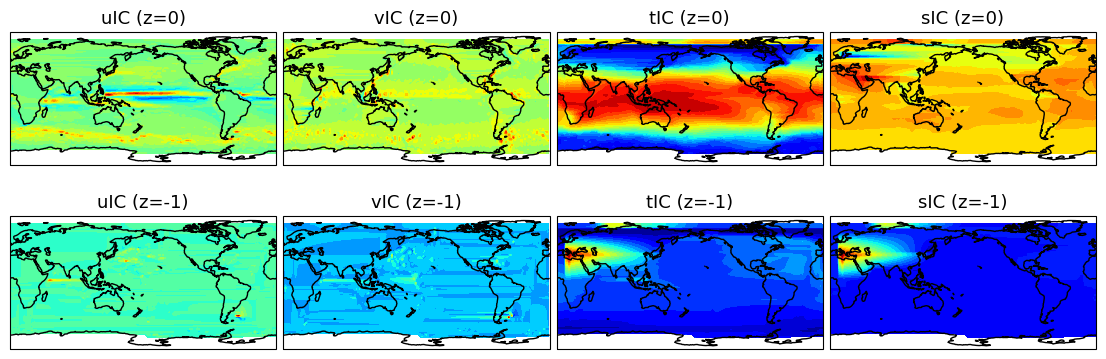

In [13]:
# plot the final IC
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(11, 4), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

plot(axes[0,0], uIC.where(uIC!=0)[0], 'uIC (z=0)')
plot(axes[0,1], vIC.where(vIC!=0)[0], 'vIC (z=0)')
plot(axes[0,2], tIC.where(tIC!=0)[0], 'tIC (z=0)')
plot(axes[0,3], sIC.where(sIC!=0)[0], 'sIC (z=0)')
plot(axes[1,0], uIC.where(uIC!=0)[-1], 'uIC (z=-1)')
plot(axes[1,1], vIC.where(vIC!=0)[-1], 'vIC (z=-1)')
plot(axes[1,2], tIC.where(tIC!=0)[-1], 'tIC (z=-1)')
plot(axes[1,3], sIC.where(sIC!=0)[-1], 'sIC (z=-1)')

fig.tight_layout(pad=0.5)

### 2.6 输出所需文件
我们将刚刚准备好的温度初始场、地形写成二进制文件。

In [ ]:
def writeBinary(var, filename, prec):
    if prec == '32':
        stype = '>f4'
    elif prec == '64':
        stype = '>f8'
    else:
        raise Exception('unsupported precision')
    
    fid = open(filename, "wb")
    fid.write(var.astype(stype).values.tobytes())
    fid.close()

# write bath
writeBinary(bath, 'ETOPO/topo.bin', '32')
# write forcings
writeBinary(u10Interp, 'NCEP/u10Interp.bin', '32')
writeBinary(v10Interp, 'NCEP/v10Interp.bin', '32')
writeBinary(T2mInterp, 'NCEP/T2mInterp.bin', '32')
writeBinary(sh2Interp, 'NCEP/sh2Interp.bin', '32')
writeBinary(dswInterp, 'NCEP/dswInterp.bin', '32')
writeBinary(dlwInterp, 'NCEP/dlwInterp.bin', '32')
writeBinary(prtInterp/1000, 'NCEP/prtInterp.bin', '32') # 除以密度，转换单位，从 kg/m^2/s 到 m/s
writeBinary(runInterp, 'NCEP/runInterp.bin', '32')
# write ICs (22层数据)
writeBinary(uIC, 'SODA/uIC.bin', '32')
writeBinary(vIC, 'SODA/vIC.bin', '32')
writeBinary(tIC, 'SODA/tIC.bin', '32')
writeBinary(sIC, 'SODA/sIC.bin', '32')

print(f"初始场数据形状: uIC={uIC.shape}, vIC={vIC.shape}, tIC={tIC.shape}, sIC={sIC.shape}")

In [ ]:
# 验证22层数据
print(f"深度层数: {len(Z)}")
print(f"深度层定义: {Z.values}")
print(f"深度层厚度: {dZ.values}")
print(f"初始场层数: uIC.shape[0]={uIC.shape[0]}, 应该等于22")


### 2.7 选取模式输出诊断量

修改data.diagnostics
查看available_diagnostics.log（运行模型后才会由模型生成，表示当前设置可以提供的模式输出量）

- [ ] 指定输出变量；
- [ ] 指定输出频率；
- [ ] 指定输出路径和文件名；